In [ ]:
# cost sensitive random forest with custom class weightings
from collections import Counter
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import make_pipeline
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from imblearn.under_sampling import RandomUnderSampler
from sklearn.inspection import permutation_importance

# Running analysis on Ainciburu

In [ ]:
data = pd.read_csv("/ibex/user/sotoorda/masterh1/public_data_analysis/ML_analysis/objects/CSV/ainci_H1_related_genes.csv")

# Filter for only ProB, PreB, HSC and MPP
filtered_data = data[data["cell_type"].isin(["HSC", "MPP", "Eo/B/Mast", "GMP", 'MDP', 'MEP', 'ERP'])]
counter = Counter(filtered_data["cell_type"])
print(counter)

Counter({'HSC': 1370, 'MPP': 906, 'GMP': 779, 'ERP': 606, 'MEP': 409, 'MDP': 273, 'Eo/B/Mast': 132})


In [ ]:
X = filtered_data.drop(columns=["cell_type", "cell_barcode", "lineage"])  # Features (gene expression)
y = filtered_data["cell_type"]  # Target (cell_type)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

/ibex/user/sotoorda/conda-environments/test_env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/ibex/user/sotoorda/conda-environments/test_env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


                   pre       rec       spe        f1       geo       iba       sup

        ERP       0.61      0.59      0.94      0.60      0.74      0.53       155
  Eo/B/Mast       0.19      0.57      0.93      0.28      0.73      0.51        30
        GMP       0.64      0.57      0.93      0.60      0.73      0.51       198
        HSC       0.86      0.83      0.95      0.84      0.88      0.77       319
        MDP       0.64      0.88      0.97      0.74      0.92      0.84        72
        MEP       0.35      0.46      0.89      0.39      0.64      0.39       124
        MPP       0.67      0.40      0.95      0.50      0.62      0.36       221

avg / total       0.66      0.62      0.94      0.63      0.76      0.57      1119



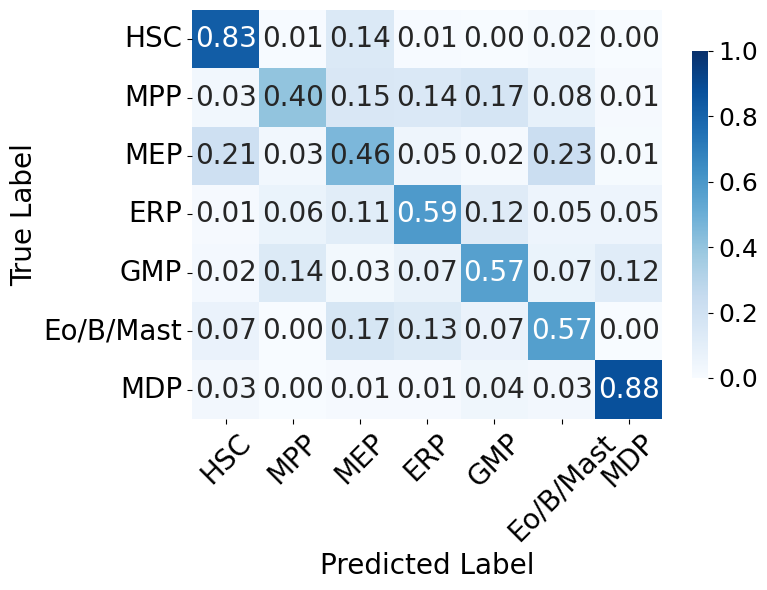

In [ ]:
pipeline = make_pipeline(
    RandomUnderSampler(random_state=42),   # Undersampling    
    RandomForestClassifier(n_estimators=150, random_state=42)  # Random Forest
)

pipeline.fit(X_train, y_train)

# Classify and report the results
print(classification_report_imbalanced(y_test, pipeline.predict(X_test)))

# Make predictions
y_pred = pipeline.predict(X_test)

# Define label order
desired_order = ["HSC", "MPP", "MEP","ERP", "GMP", "Eo/B/Mast", "MDP"]

# Compute normalized confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Convert to DataFrame with current labels
cm_df = pd.DataFrame(cm_normalized, index=np.unique(y_test), columns=np.unique(y_test))

# Reorder the DataFrame based on the desired order, filling missing labels with 0
cm_df = cm_df.reindex(index=desired_order, columns=desired_order, fill_value=0)

# Plot heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm_df, annot=True, fmt='.2f', cmap='Blues', xticklabels=desired_order, yticklabels=desired_order, annot_kws={"size": 20}, 
        vmin=0, vmax=1, cbar_kws={"shrink": 0.8})
# Titles and axis labels
plt.xlabel("Predicted Label", fontsize=20)
plt.ylabel("True Label", fontsize=20)
# plt.title("Xpand", fontsize=20, fontweight="bold")
# Axis tick label sizes
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=20)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=20)
# Access the colorbar and change number size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=18)
plt.tight_layout()
plt.savefig("/ibex/user/sotoorda/masterh1/public_data_analysis/3_datasets_analysis/plots/Manuscript_figure/Panel_1/Confusion_matrices/Ainciburu_confusion_matrix.pdf", bbox_inches="tight")
plt.savefig("/ibex/user/sotoorda/masterh1/public_data_analysis/3_datasets_analysis/plots/Manuscript_figure/Panel_1/Confusion_matrices/Ainciburu_confusion_matrix.svg", bbox_inches="tight", format="svg")
plt.show()

## Feature Importance

/tmp/ipykernel_2820153/641117670.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)


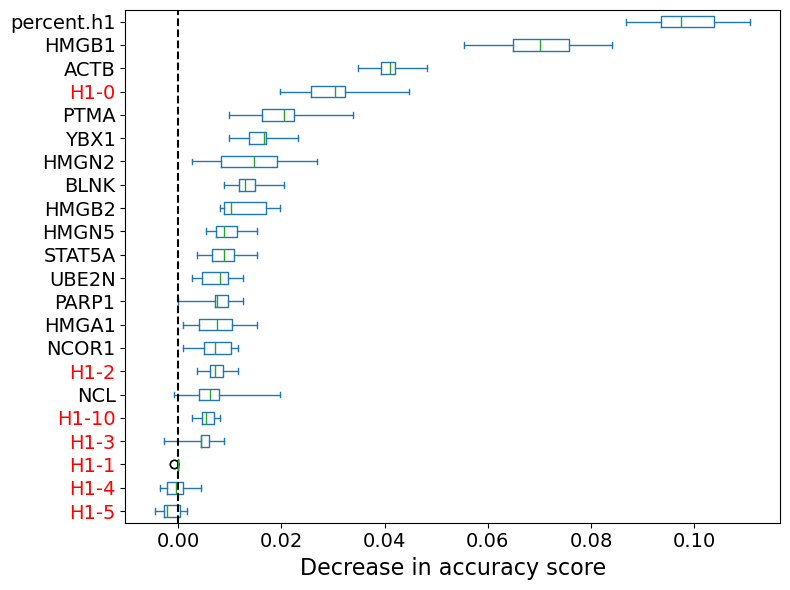

In [ ]:
# Extract feature names
feature_names = X_train.columns.tolist()
rf_model = pipeline.named_steps["randomforestclassifier"]

# Perform permutation importance
result = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2)
forest_importances = pd.Series(result.importances_mean, index=feature_names)

# Define H1 genes
h1_genes = {"H1-0", "H1-1", "H1-2", "H1-3", "H1-4", "H1-5", "H1-10"}

# Get top 15 non-H1 genes
non_h1_features = [gene for gene in forest_importances.index if gene not in h1_genes]
top15_non_h1 = forest_importances[non_h1_features].sort_values(ascending=False).head(15).index.tolist()

# Keep all H1 genes that are in the importances
h1_features_present = [gene for gene in forest_importances.index if gene in h1_genes]
final_features = list(set(top15_non_h1 + h1_features_present))

# Prepare DataFrame of importances
sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)

# Subset and sort by mean importance
importances_filtered = importances[final_features]
mean_importances = importances_filtered.mean().sort_values(ascending=True)
importances_filtered = importances_filtered[mean_importances.index]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))  # Increase height
importances_filtered.plot.box(vert=False, whis=10, ax=ax)

# Highlight H1 genes in red
labels = ax.get_yticklabels()
for label in labels:
    if label.get_text() in h1_genes:
        label.set_color("red")

# Additional formatting
# ax.set_title("Permutation Importances")
# plt.title("Xpand", fontsize=16, fontweight="bold")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score", fontsize=16)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
fig.tight_layout()
plt.savefig("/ibex/user/sotoorda/masterh1/public_data_analysis/3_datasets_analysis/plots/Manuscript_figure/Panel_1/Confusion_matrices/Ainciburu_importances.pdf", bbox_inches="tight")
plt.savefig("/ibex/user/sotoorda/masterh1/public_data_analysis/3_datasets_analysis/plots/Manuscript_figure/Panel_1/Confusion_matrices/Ainciburu_importances.svg", bbox_inches="tight", format="svg")
plt.show()


In [ ]:
# Build a table with the permutation importance order and mean importance for every gene
importance_table = pd.DataFrame({
    "gene": feature_names,
    "mean_importance": result.importances_mean,
})

# Rank genes from highest to lowest mean importance
importance_table["importance_order"] = (
    importance_table["mean_importance"].rank(method="first", ascending=False).astype(int)
)

# Sort by importance order
importance_table = importance_table.sort_values("importance_order")[["gene", "importance_order", "mean_importance"]]

# Save the full table to the provided folder
output_path = "/ibex/user/sotoorda/masterh1/public_data_analysis/ML_analysis/Feature_importance_order_csv/Ainciburu_feature_importance_order.csv"
importance_table.to_csv(output_path, index=False)

# Display the table
importance_table

# Running analysis on Li Dataset

In [ ]:
data = pd.read_csv("/ibex/user/sotoorda/masterh1/public_data_analysis/ML_analysis/objects/CSV/li_H1_related_genes.csv")

# Filter for only ProB, PreB, HSC and MPPxs
filtered_data = data[data["cell_type"].isin(["ProB", "PreB", "HSC", "MPP", 'GMP', 'ERP'])]
counter = Counter(filtered_data["cell_type"])
print(counter)

Counter({'GMP': 331, 'HSC': 308, 'ProB': 261, 'PreB': 240, 'MPP': 176, 'ERP': 133})


In [ ]:
X = filtered_data.drop(columns=["cell_type", "cell_barcode", "lineage"])  # Features (gene expression)
y = filtered_data["cell_type"]  # Target (cell_type)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

/ibex/user/sotoorda/conda-environments/test_env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/ibex/user/sotoorda/conda-environments/test_env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


                   pre       rec       spe        f1       geo       iba       sup

        ERP       0.24      0.52      0.89      0.33      0.68      0.45        23
        GMP       0.74      0.33      0.96      0.46      0.57      0.30        87
        HSC       0.77      0.74      0.92      0.76      0.83      0.67        98
        MPP       0.33      0.33      0.91      0.33      0.55      0.28        43
       PreB       0.87      0.94      0.98      0.90      0.96      0.91        48
       ProB       0.69      0.92      0.91      0.79      0.92      0.84        64

avg / total       0.68      0.64      0.93      0.63      0.75      0.58       363



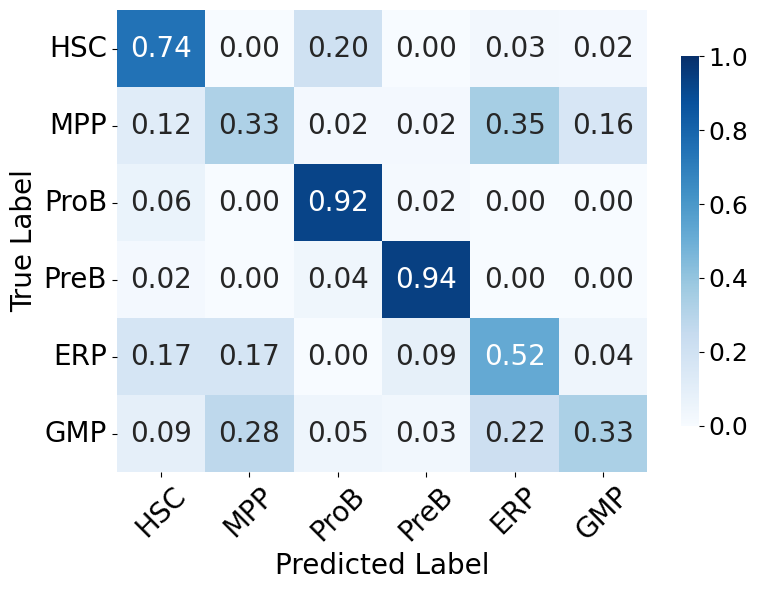

In [ ]:
pipeline = make_pipeline(
    RandomUnderSampler(random_state=42),   # Undersampling    
    RandomForestClassifier(n_estimators=150, random_state=42)  # Random Forest
)

pipeline.fit(X_train, y_train)

# Classify and report the results
print(classification_report_imbalanced(y_test, pipeline.predict(X_test)))

# Make predictions
y_pred = pipeline.predict(X_test)

# Define label order
desired_order = ["HSC", "MPP", "ProB", "PreB", "ERP", "GMP"]

# Compute normalized confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Convert to DataFrame with current labels
cm_df = pd.DataFrame(cm_normalized, index=np.unique(y_test), columns=np.unique(y_test))

# Reorder the DataFrame based on the desired order, filling missing labels with 0
cm_df = cm_df.reindex(index=desired_order, columns=desired_order, fill_value=0)

# Plot heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm_df, annot=True, fmt='.2f', cmap='Blues', xticklabels=desired_order, yticklabels=desired_order, annot_kws={"size": 20}, 
        vmin=0, vmax=1, cbar_kws={"shrink": 0.8})
# Titles and axis labels
plt.xlabel("Predicted Label", fontsize=20)
plt.ylabel("True Label", fontsize=20)
# plt.title("Xpand", fontsize=20, fontweight="bold")
# Axis tick label sizes
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=20)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=20)
# Access the colorbar and change number size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=18)
plt.tight_layout()
plt.savefig("/ibex/user/sotoorda/masterh1/public_data_analysis/3_datasets_analysis/plots/Manuscript_figure/Panel_1/Confusion_matrices/Li_confusion_matrix.pdf", bbox_inches="tight")
plt.savefig("/ibex/user/sotoorda/masterh1/public_data_analysis/3_datasets_analysis/plots/Manuscript_figure/Panel_1/Confusion_matrices/Li_confusion_matrix.svg", bbox_inches="tight", format="svg")
plt.show()

## Feature importance

/tmp/ipykernel_2662658/612045743.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)


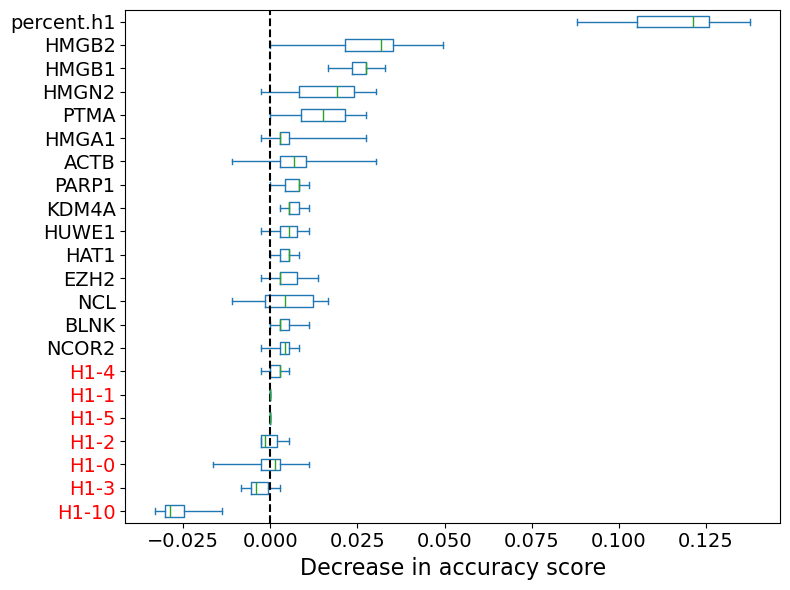

In [ ]:
# Extract feature names
feature_names = X_train.columns.tolist()
rf_model = pipeline.named_steps["randomforestclassifier"]

# Perform permutation importance
result = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2)
forest_importances = pd.Series(result.importances_mean, index=feature_names)

# Define H1 genes
h1_genes = {"H1-0", "H1-1", "H1-2", "H1-3", "H1-4", "H1-5", "H1-10"}

# Get top 15 non-H1 genes
non_h1_features = [gene for gene in forest_importances.index if gene not in h1_genes]
top15_non_h1 = forest_importances[non_h1_features].sort_values(ascending=False).head(15).index.tolist()

# Keep all H1 genes that are in the importances
h1_features_present = [gene for gene in forest_importances.index if gene in h1_genes]
final_features = list(set(top15_non_h1 + h1_features_present))

# Prepare DataFrame of importances
sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)

# Subset and sort by mean importance
importances_filtered = importances[final_features]
mean_importances = importances_filtered.mean().sort_values(ascending=True)
importances_filtered = importances_filtered[mean_importances.index]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))  # Increase height
importances_filtered.plot.box(vert=False, whis=10, ax=ax)

# Highlight H1 genes in red
labels = ax.get_yticklabels()
for label in labels:
    if label.get_text() in h1_genes:
        label.set_color("red")

# Additional formatting
# ax.set_title("Permutation Importances")
# plt.title("Xpand", fontsize=16, fontweight="bold")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score", fontsize=16)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
fig.tight_layout()
plt.savefig("/ibex/user/sotoorda/masterh1/public_data_analysis/3_datasets_analysis/plots/Manuscript_figure/Panel_1/Confusion_matrices/Li_importances.pdf", bbox_inches="tight")
plt.savefig("/ibex/user/sotoorda/masterh1/public_data_analysis/3_datasets_analysis/plots/Manuscript_figure/Panel_1/Confusion_matrices/Li_importances.svg", bbox_inches="tight", format="svg")
plt.show()


In [ ]:
# Build a table with the permutation importance order and mean importance for every gene
importance_table = pd.DataFrame({
    "gene": feature_names,
    "mean_importance": result.importances_mean,
})

# Rank genes from highest to lowest mean importance
importance_table["importance_order"] = (
    importance_table["mean_importance"].rank(method="first", ascending=False).astype(int)
)

# Sort by importance order
importance_table = importance_table.sort_values("importance_order")[["gene", "importance_order", "mean_importance"]]

# Save the full table to the provided folder
output_path = "/ibex/user/sotoorda/masterh1/public_data_analysis/ML_analysis/Feature_importance_order_csv/Li_feature_importance_order.csv"
importance_table.to_csv(output_path, index=False)

# Display the table
importance_table